
0: 416x640 17 cars, 4 buss, 2 trucks, 151.1ms
Speed: 3.6ms preprocess, 151.1ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)


(np.float64(-0.5), np.float64(283.5), np.float64(177.5), np.float64(-0.5))

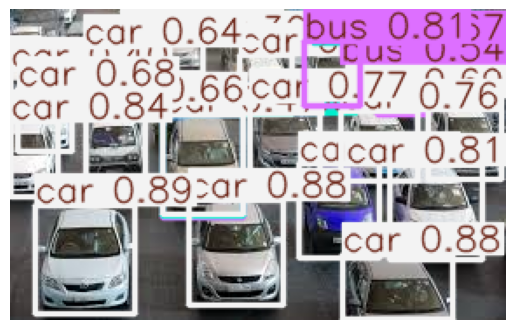

In [4]:
# Install ultralytics (run once)
!pip install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLO model
model = YOLO("yolov8n.pt")

# Load image
img = cv2.imread("test.jpg")

# Run detection
results = model(img)

# Show result
res_plotted = results[0].plot()
plt.imshow(res_plotted)
plt.axis('off')

(np.float64(-0.5), np.float64(283.5), np.float64(177.5), np.float64(-0.5))

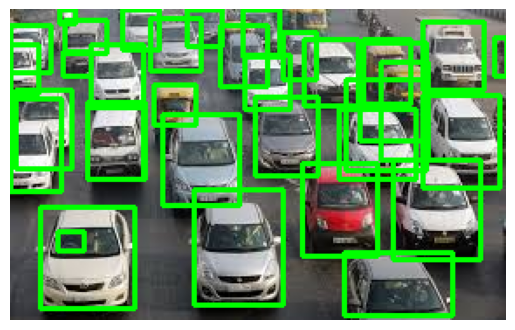

In [5]:
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load pretrained Faster R-CNN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load image
img = Image.open("test.jpg")
transform = torchvision.transforms.ToTensor()
img_tensor = transform(img)

# Prediction
with torch.no_grad():
    predictions = model([img_tensor])

# Draw boxes
img_cv = cv2.imread("test.jpg")
for box, score in zip(predictions[0]['boxes'], predictions[0]['scores']):
    if score > 0.5:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_cv, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.axis('off')